<img src=".\assets\on_black.png" alt="netective logo" style="width:18%;">

Compare networks based on their structure and performance statistics.
<br><br>
## Python Module Tutorial

Explore the main features of the Python module for network comparison.

- For a tutorial on the command-line interface, refer to [this link]().
- Access the web service for small jobs [here]().

---

The module consists of two submodules: `structure` and `stats`, each with module-level functions for convenient usage.

In this guide, we'll cover the following topics:

1. **Module-level functions** 📦
2. **Submodule `structure`** 🕸️📐
   Useful for comparing networks with different node IDs.

3. **Submodule `stats`** 📊
   Requires networks to share node IDs. Useful for comparing inferred networks against a gold standard.

<br>

Make sure to have netective installed:

In [1]:
# %pip install netective

<br>

### Module-level functions 📦

The module-level functions empower users, even those with basic Python proficiency, to seamlessly employ netective to characterize network structure, compare networks, and assess inference performance.

In [2]:
# Third-party imports
import networkx as nx
from scipy.stats import spearmanr

#### characterize network structure

C:\Users\jmere\Dropbox (FreyreLab)\netective\src\netective\structure\dataviz.py:128: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


(<Figure size 200x780 with 1 Axes>, <Figure size 1200x750 with 11 Axes>)

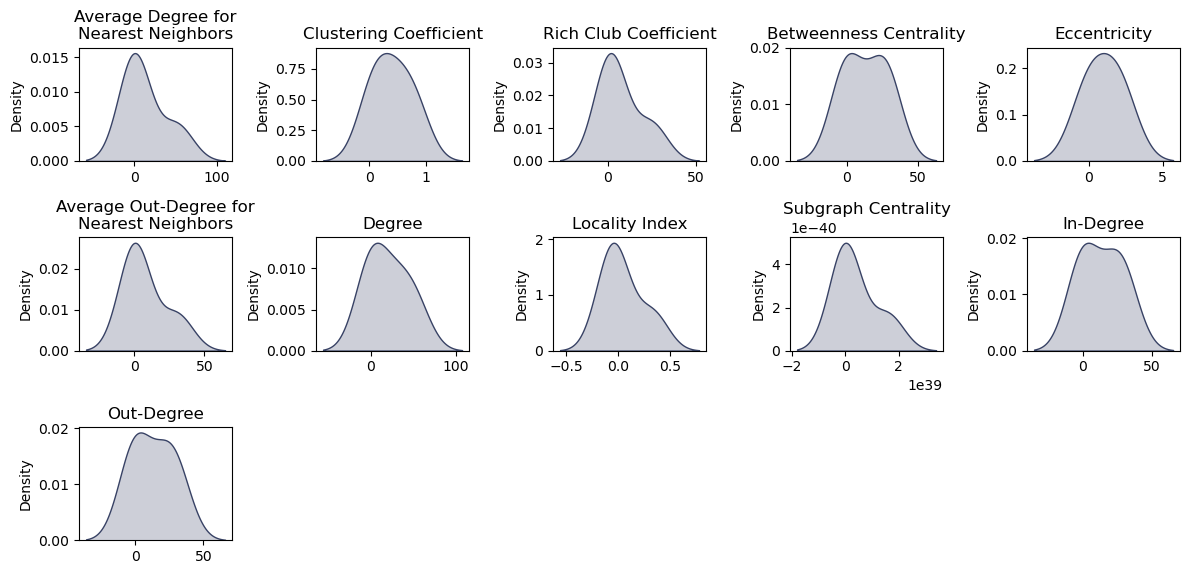

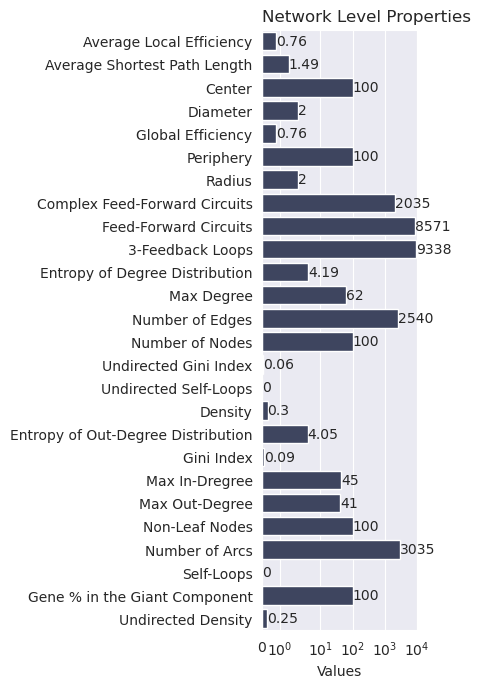

In [7]:
from netective import characterize_network

# Let's create a random network to characterize
G = nx.erdos_renyi_graph(100, 0.3, directed=True)

# Characterize the network is as simple as calling the function with the network and an identifier as arguments
characterize_network(G, "my_network")

Networks may have different size. Use the norm parameter to get normalized values.

In [ ]:
# norm parameter allows you to normalize data using different approaches depending on the nature of the networks analyzed
# default is None for no normalization, uses raw data
# norm = "network" normalize the network by the network size

characterize_network(G, "my_network", norm="network", verbose='info')

In [ ]:
# norm = "biological" normalize the network by the number of regulators

characterize_network(G, "my_network", norm="biological")

Netective v1.0 uses a total of 28 network properties for characterization and comparison:

`Node-Level Properties`
- In-Degree (InDegre)
- Out-Degree (OutDegre)
- Locality Index (LocalityIndex)
- Subgraph Centrality (SubgraphCentrality)
- Average Degree of Nearest Neighbors using out-out degree (AverageOutDegreeNearestNeighbors)
- Average Degree of Nearest Neighbors using undirected network (AverageDegreeNearestNeighbors)
- Clustering Coefficient (ClusteringCoefficient)
- Rich Club Coefficient (RichClub)
- Betweenness Centrality (BetweennessCentrality)
- Eccentricity (Eccentricity)

`Network-Level Properties`
- Entropy of Degree Distribution (EntropyPKout)
- Gini Index (GiniIndex)
- Max In-Degree (MaxInDegree)
- Max Out-Degree (MaxOutDegree)
- Regulators (Regulators)
- Self-Regulations (SelfRegulations)
- Density (Density)
- Complex Feed-Forward Circuits (ComplexFeedForwardCircuits)
- 3-Feedback Loops (FeedbakcLoops_3)
- Average Clustering Coefficient (AverageClusteringCoefficient)
- Gene % in the Giant Component (GenesintheGiantComponent)
- Average Local Efficiency (AverageLocalEfficiency)
- Average Shortest Path Length (AverageShortestPathLength)
- Center (Center)
- Diameter (Diameter)
- Global Efficiency (GlobalEfficiency)
- Periphery (Periphery)
- Radius (Radius)

***correct spelling for list in parenthesis***

characterize_network function allows you to provide a list of chosen properties to use if you do not want to use the complete set, using the parameter selected_props ***default is all properties***

(<Figure size 200x120 with 1 Axes>, None)

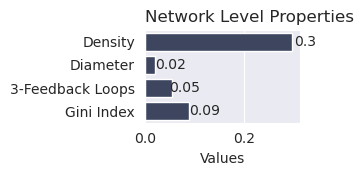

In [11]:
# using the same network

my_properties = ['Gini Index', 'Density', 'Diameter', 'LocalityIndex', 'InDegree', 'RichClub', '3-Feedback Loops']

characterize_network(G, "my_network", norm="network", selected_props= my_properties)

#### compare networks based on their structure

In [ ]:
from netective import compare_structure
import networkx as nx

# Let's create a random network to characterize
G = nx.erdos_renyi_graph(100, 0.3, directed=True)
# Let's create a second network to compare to the first one.
H = nx.path_graph(50, create_using=nx.DiGraph)

# Comparing both networks is as simple as calling the function with a dictionary of networks.
networks = {"my_network_G": G, "my_network_H": H}
compare_structure(networks, return_prop_dicts=False, erdos_renyi=30, verbose='info', norm="network");

In [ ]:
from netective import compare_structure
import networkx as nx

# Let's create a random network to characterize
G = nx.erdos_renyi_graph(100, 0.3, directed=True)
F = nx.erdos_renyi_graph(50, 50/50**2, directed=True)
# Let's create a second network to compare to the first one.
H = nx.path_graph(50, create_using=nx.DiGraph)

# Comparing both networks is as simple as calling the function with a dictionary of networks.
networks = {"my_network_G": G, "my_network_H": H, "my_network_F": F}
compare_structure(networks, return_prop_dicts=False, verbose='info', norm="network");

In [ ]:
# pearsonr is used by default to compare networks. Other methods are available using the parameter association_metric.
# compare_structure runs in parallel by default. Use workers to specify the number of processes to run in parallel.
# TODO definir bien cómo es la comparación de redes

compare_structure(networks, workers=2, association_metric=spearmanr);

In [ ]:
# just like characterize_network, compare_structure function allows you to provide the list of chosen properties for analysis using the parameter selected_props

# my_properties = ['EntropyPKout', 'ClusteringCoefficient', 'OutDegree', 'Density', 'Regulators']
my_properties = ['Complex Feed-Forward Circuits', 'Feed-Forward Circuits', '3-Feedback Loops']
# ERROR
compare_structure(networks, workers=2, association_metric=spearmanr, selected_props= my_properties);

In [ ]:
# Lets create a dict with 10 random networks to see the power of compare_structure

erdos_nets = {f'erdos_{i}': nx.fast_gnp_random_graph(100, 0.1, directed=True) for i in range(10)}
sf_nets = {f'SF_{i}': nx.DiGraph(nx.scale_free_graph(100)) for i in range(10)}

name_nets = {**erdos_nets, **sf_nets}

compare_structure(name_nets);

In [ ]:
# Netective is also capable to compare a directed network with an undirected one
# A subset of properties they share is selected for analysis
# Biological normalization not recommended for this type of comparison

# Let's create a random UNDIRECTED network.
G = nx.erdos_renyi_graph(100, 0.3, directed=False)
# Let's create a second network to compare to the first one. Notice this is a directed network
H = nx.path_graph(50, create_using=nx.DiGraph)

networks = {"my_network_G": G, "my_network_H": H}
compare_structure(networks, norm='network', workers='auto');

<br>

### **Submodule `structure`** 🕸️📐

In [ ]:
from netective.structure.structure import Structure

In [ ]:
# The object Structure allows you to observe a graph constantly.

G = nx.erdos_renyi_graph(100, 0.2, directed=True)
s = Structure(G)
s.get_props()

In [ ]:
# if the graphs has not changed, it returned the curret props dict
s.get_props()

In [ ]:
# but recalculates the props if the graph changes without creating a new instance of the class.
G.add_edge("A", "B")
s.get_props()

In [ ]:
s.norm = "network"
s.get_props()

## Classify networks

In [ ]:
import networkx as nx
from netective import classify_networks

# Let's create a random network to characterize
networks = {
    'G': nx.erdos_renyi_graph(100, 0.3, directed=True),
    'H': nx.path_graph(50, create_using=nx.DiGraph),
    'F': nx.erdos_renyi_graph(50, 0.4, directed=True),
    'I': nx.erdos_renyi_graph(300, 0.2, directed=True),
    'J': nx.path_graph(100, create_using=nx.DiGraph),
}

classify_networks(networks)

### Structure advanced: Include your own properties

In [ ]:
# To be able to include your own properties, you need to import the parent class first.
import networkx as nx
from netective.structure.properties import _Property, return_scalar, use_selfloops, check_raw_value, NormalizationError

# Then, you can create your own class inheriting from _Property.
# and implement the corresponding methods. You may want to use this class as a template.
# The decorators are used to define the required preprocessing for the input graph. Import them from netective.structure.properties too.
# Optionally, you may also want to import NormalizationError to raise an error if the property cannot be normalized.
@return_scalar
@use_selfloops
class MyProperty(_Property):
    """MyProperty class to use as a template for custom properties.

    Methods:
        compute: Compute the number of nodes of a graph.
        norm_biol: Not implemented.
        norm_network: Not implemented.
    """

    CLASS_NAME = "My Property" # Human readable name of the property.

    def __init__(self, G: nx.Graph):
        super().__init__(G)

    def compute(self) -> int:
        """Compute the number of nodes.

        Returns:
            int: always return 101.
        """
        return 101

    @check_raw_value
    def norm_biol(self) -> None:
        raise NormalizationError(
            "Not implemented for this example."
        )

    @check_raw_value
    def norm_network(self) -> float:
        raise NormalizationError(
            "Not implemented for this example."
        )

In [ ]:
# Pass globals() as the include_env parameter to the function characterize_network.

from netective import characterize_network
G = nx.erdos_renyi_graph(100, 0.3, directed=True) # random network

characterize_network(G, "my_network", include_env=globals())

In [ ]:
# This also works for compare_structure but you need to save the properties in a file first to import it
# We are using return_prop_dicts = True to get the properties dicts of the networks ans see our new property (My Property).
from netective import compare_structure

import inspect
import my_props # here my_props is in the same directory
my_props_env = dict(inspect.getmembers(my_props))
# Let's create two networks to compare
G = nx.erdos_renyi_graph(100, 0.3, directed=True)
H = nx.path_graph(50, create_using=nx.DiGraph)
networks = {"my_network_G": G, "my_network_H": H}
scalar, dist_moments = compare_structure(networks, return_prop_dicts=True, erdos_renyi=2, verbose='debug', include_env=my_props_env)


In [ ]:
# Let's check for our new property
scalar['my_network_G']['My Property']

# Note: If this raises a KeyError, make sure your property is included in the analysis.
# Check the norm parameter in compare_structure. Remember that properties without the required normalization are excluded.

### **Submodule `stats`** 🕸️📐

This module allows you to evaluate an inferred network against a gold standard.

In [ ]:
# import the module
from netective.stats import stats

In [ ]:
from netective.utils import parse_network
pred = 'assets\\short_100226_v2019_sFL_dAllInc_BSs.pred'
gs = 'assets\\short_GS.txt'


pred_graph = parse_network(pred, delimiter='\t', directed=True, score=True, use_position_as_score=True)

gold_standard_graph = parse_network(gs, delimiter='\t', directed=True)

bin_stats = stats.NetworkInferenceStats(gold_standard_graph, pred_graph, greater_score_is_better=False, allow_self_loops=True, cutoff=False)
# cutoff is set to False to avoid trimming the prediction file

In [8]:
# get the area under the ROC curve
bin_stats.area_under_roc_curve()

0.5144585089639357

In [9]:
bin_stats.f1_score(), bin_stats.precision(), bin_stats.recall(), bin_stats.accuracy()

(0.05225225225225225, 0.2636363636363636, 0.029, 0.9989046230737193)

<Axes: title={'right': 'Optimal cutoff = 963'}, xlabel='Score', ylabel='Precision and recall'>

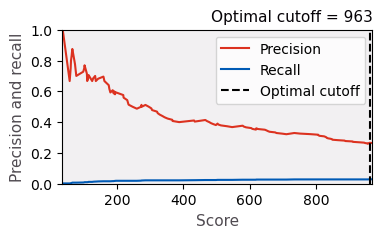

In [10]:
bin_stats.optimal_cutoff_plot()

In [ ]:
import sklearn as sk
sk.__version__

In [ ]:
# get the area under the precision-recall curve
bin_stats.area_under_precision_recall_curve()

In [ ]:
# plot the precision recall curve
bin_stats.plot_precision_recall_curve()

In [ ]:
# plot the ROC curve
bin_stats.plot_roc_curve()

The computations and plots generated above, use the cutoff provided at the instatiation of the NetworkInferenceStats class.

If you want to change the cutoff value, you can do so by changing the cutoff attribute of the class and then calling the plot functions again.

In [ ]:
bin_stats.cutoff = 400
bin_stats.plot_precision_recall_curve()

You can also indicate the cutoff value when calling the method for a specific application:

In [ ]:
bin_stats.plot_precision_recall_curve(cutoff=100)

This won't change the associated cutoff value

In [ ]:
bin_stats.plot_precision_recall_curve()